# 05 — Overstock Analysis

## GulfMart Retail Inventory Analytics

`03_inventory_kpis.ipynb` found systemic, severe overstock (annualized
turnover ~0.0035, GMROI ~0.0044, 99.2% of products flagged excess) and
traced it to supplier minimum-order-quantities (MOQ) flooring
replenishment orders well above actual demand. This notebook quantifies
that finding in dollar terms and measures, order by order, how much of
it is directly attributable to the MOQ mechanism specifically.

**How "excess" is defined here -- grounded in the model's own policy,
not an external threshold:**

```text
Excess Units = max(closing_stock - target_stock_level, 0)
Excess Value = Excess Units x unit_cost
```

`target_stock_level` is the inventory model's own computed replenishment
target (lead-time demand + review-period demand + safety stock). Anything
held above that isn't excess by an arbitrary rule we're imposing -- it's
excess by the system's own stated logic. This is a meaningfully stronger
basis than the fixed 365-day coverage threshold used descriptively in
earlier notebooks.

**MOQ root-cause attribution** compares what was actually ordered
(`planned_order_quantity`) against the policy target
(`target_stock_level`) at every real replenishment event -- a direct,
order-by-order measurement, not an estimate.

**Capital recapture (Section 8) is a retrospective counterfactual, not a
forecast.** It estimates how much of the historical MOQ overshoot this
specific dataset would not have accumulated under a capped-MOQ rule,
holding the one-time order quantity change constant. It does NOT
re-simulate how a smaller order would have changed every subsequent
day's closing stock, future reorder timing, or order sizes -- all of
which would genuinely change under a real policy change. Treat this as
a defensible order-of-magnitude estimate for a business recommendation,
not a validated projection.


## 1. Setup

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from overstock_analysis import (
    compute_excess_value,
    summarize_excess_by,
    compute_moq_attribution,
    estimate_moq_cap_recapture,
)

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\GitHub\retail-inventory-analytics


## 2. Load Data

In [14]:
dim_product = pd.read_csv(DATA_CLEANED_DIR / "dim_product.csv")
dim_store = pd.read_csv(DATA_CLEANED_DIR / "dim_store.csv")
fact_inventory = pd.read_csv(DATA_RAW_DIR / "fact_inventory.csv.gz")

print(f"dim_product:    {len(dim_product):,} rows")
print(f"dim_store:      {len(dim_store):,} rows")
print(f"fact_inventory: {len(fact_inventory):,} rows")


dim_product:    500 rows
dim_store:      20 rows
fact_inventory: 10,960,000 rows


## 3. Compute Excess Inventory Value

In [15]:
fact_inventory_excess = compute_excess_value(fact_inventory, dim_product)

fact_inventory_excess = fact_inventory_excess.merge(
    dim_store[["store_id", "store_name", "store_type", "region"]],
    on="store_id",
    how="left",
)



Computing Excess Inventory Value
Rows: 10,960,000
Rows above target_stock_level: 10,883,556 (99.3%)
Total excess_value across all rows (period-cumulative, not a balance): 13,726,848,377,533.79


## 4. Overall Picture

What share of total inventory value, on a typical day, is excess above
policy target.

In [16]:
fact_inventory_excess["inventory_value"] = (
    fact_inventory_excess["closing_stock"] * fact_inventory_excess["unit_cost"]
)

daily_totals = fact_inventory_excess.groupby("date").agg(
    total_inventory_value=("inventory_value", "sum"),
    total_excess_value=("excess_value", "sum"),
).reset_index()

avg_daily_inventory_value = daily_totals["total_inventory_value"].mean()
avg_daily_excess_value = daily_totals["total_excess_value"].mean()
excess_share_of_inventory_pct = avg_daily_excess_value / avg_daily_inventory_value * 100

print(f"Average daily total inventory value:   {avg_daily_inventory_value:,.2f}")
print(f"Average daily total excess value:      {avg_daily_excess_value:,.2f}")
print(f"Excess as % of total inventory value:  {excess_share_of_inventory_pct:.2f}%")


Average daily total inventory value:   12,646,166,082.54
Average daily total excess value:      12,524,496,694.83
Excess as % of total inventory value:  99.04%


## 5. Worst Offenders — Products

Time-averaged excess value per product (average of each day's total,
not a raw period sum), so the number represents a realistic "typically
how much capital is tied up," not an artifact of the 1,096-day period.

In [17]:
product_excess = summarize_excess_by(fact_inventory_excess, "product_id")

product_excess = product_excess.merge(
    dim_product[["product_id", "product_name", "category", "demand_class"]],
    left_index=True,
    right_on="product_id",
).sort_values("avg_excess_value", ascending=False).reset_index(drop=True)

print("Top 15 products by average excess inventory value:")
print(
    product_excess[
        ["product_id", "product_name", "category", "demand_class", "avg_excess_units", "avg_excess_value"]
    ]
    .head(15)
    .to_string(index=False)
)


Top 15 products by average excess inventory value:
product_id                       product_name      category  demand_class  avg_excess_units  avg_excess_value
  PROD0132               Laundry Product 0132     Household   Fast-moving     755203.935193      2.470650e+08
  PROD0054  Computer Accessories Product 0054   Electronics   Fast-moving     778161.925806      2.389657e+08
  PROD0189 Furniture Accessories Product 0189 Home & Living   Fast-moving     780185.593690      2.365523e+08
  PROD0122                 Audio Product 0122   Electronics Medium-moving     393468.125003      1.908517e+08
  PROD0411              Footwear Product 0411       Fashion Medium-moving     381403.836138      1.852936e+08
  PROD0322     Small Electronics Product 0322   Electronics Medium-moving     381543.545888      1.840413e+08
  PROD0416           Kitchenware Product 0416 Home & Living Medium-moving     393382.906387      1.585254e+08
  PROD0429          Canned Foods Product 0429       Grocery   Fast-mo

## 6. Worst Offenders — Stores

In [18]:
store_excess = summarize_excess_by(fact_inventory_excess, "store_id")

store_excess = store_excess.merge(
    dim_store[["store_id", "store_name", "store_type", "region"]],
    left_index=True,
    right_on="store_id",
).sort_values("avg_excess_value", ascending=False).reset_index(drop=True)

print("All 20 stores by average excess inventory value:")
print(
    store_excess[["store_id", "store_name", "store_type", "region", "avg_excess_units", "avg_excess_value"]]
    .to_string(index=False)
)


All 20 stores by average excess inventory value:
store_id         store_name  store_type   region  avg_excess_units  avg_excess_value
STORE015 GulfMart Store 015 Hypermarket  Western      2.886763e+06      6.985663e+08
STORE014 GulfMart Store 014 Hypermarket  Western      2.829564e+06      6.774727e+08
STORE016 GulfMart Store 016  E-commerce  Western      2.757679e+06      6.713274e+08
STORE007 GulfMart Store 007 Hypermarket Southern      2.725806e+06      6.660887e+08
STORE019 GulfMart Store 019 Hypermarket Southern      2.730264e+06      6.659562e+08
STORE009 GulfMart Store 009 Hypermarket Southern      2.739559e+06      6.623765e+08
STORE003 GulfMart Store 003 Supermarket  Central      2.697152e+06      6.552238e+08
STORE006 GulfMart Store 006 Supermarket  Western      2.669455e+06      6.485874e+08
STORE005 GulfMart Store 005 Supermarket  Western      2.658094e+06      6.414357e+08
STORE017 GulfMart Store 017 Supermarket  Western      2.651825e+06      6.406959e+08
STORE002 GulfMar

## 7. Concentration — Category and Pareto Analysis

In [19]:
category_excess = summarize_excess_by(fact_inventory_excess, "category")
category_excess = category_excess.sort_values("avg_excess_value", ascending=False)

print("Excess inventory value by category:")
print(category_excess.to_string())


Excess inventory value by category:
               avg_excess_units  avg_excess_value
category                                         
Grocery            1.211379e+07      2.760332e+09
Electronics        5.733659e+06      1.661409e+09
Fashion            6.114614e+06      1.594754e+09
Home & Living      5.846917e+06      1.576571e+09
Household          4.965361e+06      1.433378e+09
Beauty             6.002366e+06      1.332042e+09
Personal Care      5.715778e+06      1.105970e+09
Beverages          5.132468e+06      1.060041e+09


In [21]:
product_excess_sorted = product_excess.sort_values("avg_excess_value", ascending=False).reset_index(drop=True)

product_excess_sorted["cumulative_share_pct"] = (
    product_excess_sorted["avg_excess_value"].cumsum()
    / product_excess_sorted["avg_excess_value"].sum()
    * 100
)

n_for_80pct = (product_excess_sorted["cumulative_share_pct"] <= 80).sum() + 1

print(
    f"{n_for_80pct} of {len(product_excess_sorted):,} products "
    f"({n_for_80pct / len(product_excess_sorted):.1%}) account for 80% "
    f"of total average excess inventory value."
)


153 of 500 products (30.6%) account for 80% of total average excess inventory value.


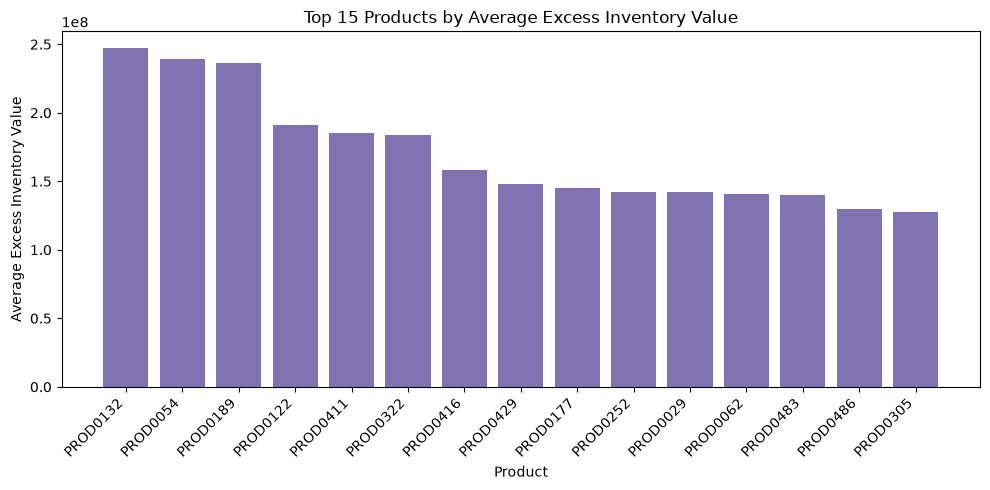

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

top15 = product_excess_sorted.head(15)

ax.bar(top15["product_id"], top15["avg_excess_value"], color="#8172B2")
ax.set_xlabel("Product")
ax.set_ylabel("Average Excess Inventory Value")
ax.set_title("Top 15 Products by Average Excess Inventory Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. MOQ Root-Cause Attribution

Direct, order-by-order measurement: how much of every replenishment
order exceeded the policy target, at the moment it was placed.

In [23]:
replenishment_events, moq_summary = compute_moq_attribution(fact_inventory_excess)
moq_summary



MOQ Root-Cause Attribution
Total replenishment orders: 730,069
Orders inflated above target by MOQ: 368,128 (50.4%)
Total order-time overshoot value (one-time, at order): 12,667,884,313.74


{'total_replenishment_orders': 730069,
 'moq_inflated_orders': 368128,
 'moq_inflated_order_share_pct': np.float64(50.423727072372614),
 'total_moq_overshoot_value': np.float64(12667884313.737022)}

## 9. Capital Recapture What-If (Retrospective Counterfactual)

**Not a forecast.** See the module docstring and the note in Section 1
for exactly what this does and does not account for.

In [24]:
recapture_results = estimate_moq_cap_recapture(replenishment_events)
recapture_results



Capital Recapture What-If (retrospective, order-time only)
  Cap at  1.5x target: 41,285,671 units / 10,166,780,324.74 value recaptured (order-time, retrospective)
  Cap at  2.0x target: 33,754,225 units / 8,359,976,829.70 value recaptured (order-time, retrospective)
  Cap at  3.0x target: 23,487,943 units / 5,818,427,570.69 value recaptured (order-time, retrospective)
  Cap at  5.0x target: 11,805,356 units / 2,834,961,144.97 value recaptured (order-time, retrospective)


,cap_multiplier,recaptured_units,recaptured_value
0,1.5,4.128567e+07,1.016678e+10
1,2.0,3.375422e+07,8.359977e+09
2,3.0,2.348794e+07,5.818428e+09
3,5.0,1.180536e+07,2.834961e+09


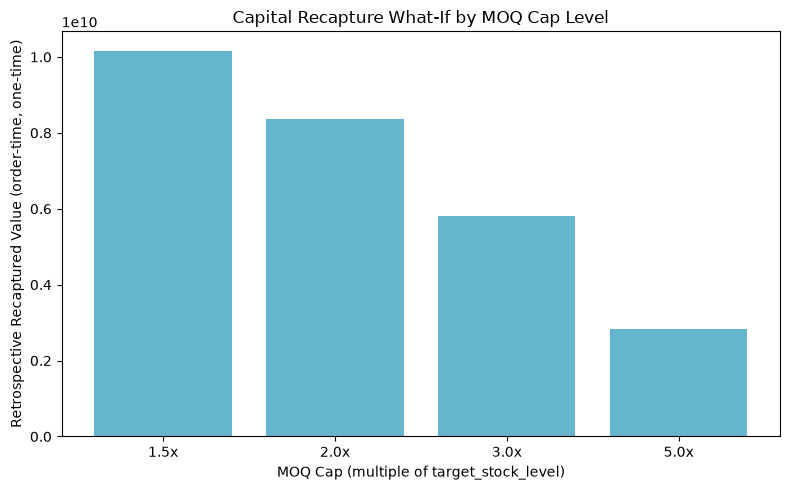

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    recapture_results["cap_multiplier"].astype(str) + "x",
    recapture_results["recaptured_value"],
    color="#64B5CD",
)
ax.set_xlabel("MOQ Cap (multiple of target_stock_level)")
ax.set_ylabel("Retrospective Recaptured Value (order-time, one-time)")
ax.set_title("Capital Recapture What-If by MOQ Cap Level")
plt.tight_layout()
plt.show()


## 10. Findings Summary

**Overall:** Average daily total inventory value across the network is
**$12.65B**; average daily excess value is **$12.52B** — **99.04%** of
all inventory value carried, on a typical day, sits above the system's
own replenishment policy target. This is not a tail problem affecting a
minority of stock; it is nearly the entire inventory position.

**Worst offenders:** Top single product is **PROD0132** (Laundry,
Household, Fast-moving) at ~$247M average excess value; the worst store
is **STORE015** (Hypermarket, Western) at ~$699M average excess value.
Notably, **PROD0367** — the product flagged repeatedly in
`04_stockout_analysis.ipynb` as closest to a real stockout — does **not**
appear among the top overstock offenders here, a meaningful cross-notebook
consistency check: the products most at risk of running out and the
products most drowning in excess are, correctly, different products.

**Concentration:** **153 of 500 products (30.6%)** account for 80% of
total average excess value — a real but moderate concentration, feeding
directly into `06_abc_analysis.ipynb`'s formal ABC classification.

**MOQ attribution (measured, not estimated):** **50.4%** of all 730,069
replenishment orders were inflated above the policy target specifically
by the supplier minimum-order-quantity floor, totaling **$12.67B** in
one-time order-level overshoot value. This is a direct, order-by-order
measurement of the root cause first identified in `03_inventory_kpis.ipynb`.

**Capital recapture (retrospective, not a forecast):** capping MOQ
enforcement at **2x target_stock_level** would, retrospectively and
holding all else constant, have avoided approximately **$8.36B** in
order-time overshoot; at a stricter 1.5x cap, approximately **$10.17B**.
These are one-time, order-level estimates — they do not model how
smaller historical orders would have changed subsequent days' closing
stock, future reorder timing, or order sizing, all of which would
genuinely differ under an actual policy change. Reported here as a
defensible order-of-magnitude business estimate, not a validated
projection.

**Overall read:** Overstock in this system is not diffuse, mysterious,
or a matter of degree — it is a near-total condition (99% of inventory
value) with a specific, directly-measured mechanism (MOQ flooring,
responsible for $12.67B of overshoot) and a moderately concentrated
distribution (30.6% of products driving 80% of the excess). That
combination — severe, measured, mechanistically explained, and
partially concentrated — is what turns this from an observation into an
actionable business recommendation: MOQ policy reform, targeted first at
the top ~150 products, is the highest-leverage intervention this
analysis has identified.

**Next step:** `06_abc_analysis.ipynb` formalizes the concentration
pattern surfaced here (153 products / 80% of excess value) into a full
ABC classification across the entire product catalog.